In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
data = pd.read_csv(
    "../datasets/processed/day14_financial_ratios_dataset.csv"
)

print("Dataset loaded successfully!")
print("Shape:", data.shape)
print(data.head())

Dataset loaded successfully!
Shape: (110, 19)
  company ticker  year  year_end_price  dividend_per_share  dividend_yield  \
0   Apple   AAPL  2015       26.315001              0.5075            1.93   
1   Apple   AAPL  2016       28.955000              0.5575            1.93   
2   Apple   AAPL  2017       42.307499              0.6150            1.45   
3   Apple   AAPL  2018       39.435001              0.7050            1.79   
4   Apple   AAPL  2019       73.412498              0.7600            1.04   

   dividend_growth dividend_growth_category  annual_stock_return  \
0              NaN               First Year                  NaN   
1             9.85                Increased                10.03   
2            10.31                Increased                46.11   
3            14.63                Increased                -6.79   
4             7.80                Increased                86.16   

  return_category  total_return  return_volatility  average_return  \
0     

In [4]:
required_columns = [
    "ticker",
    "year",
    "dividend_yield",
    "dividend_growth",
    "dividend_consistency",
    "annual_stock_return",
    "total_return",
    "return_volatility"
]

for col in required_columns:
    print(col, "->", col in data.columns)

ticker -> True
year -> True
dividend_yield -> True
dividend_growth -> True
dividend_consistency -> True
annual_stock_return -> True
total_return -> True
return_volatility -> True


In [5]:
signaling_data = data[
    [
        "ticker",
        "year",
        "dividend_yield",
        "dividend_growth",
        "dividend_consistency",
        "annual_stock_return",
        "total_return",
        "return_volatility"
    ]
].copy()

print("Signaling dataset shape:", signaling_data.shape)
print(signaling_data.head())

Signaling dataset shape: (110, 8)
  ticker  year  dividend_yield  dividend_growth  dividend_consistency  \
0   AAPL  2015            1.93              NaN                 90.91   
1   AAPL  2016            1.93             9.85                 90.91   
2   AAPL  2017            1.45            10.31                 90.91   
3   AAPL  2018            1.79            14.63                 90.91   
4   AAPL  2019            1.04             7.80                 90.91   

   annual_stock_return  total_return  return_volatility  
0                  NaN           NaN              36.16  
1                10.03         11.96              36.16  
2                46.11         47.56              36.16  
3                -6.79         -5.00              36.16  
4                86.16         87.20              36.16  


In [6]:
print("Missing values:")
print(signaling_data.isnull().sum())

Missing values:
ticker                   0
year                     0
dividend_yield           0
dividend_growth         10
dividend_consistency     0
annual_stock_return     10
total_return            10
return_volatility        0
dtype: int64


In [7]:
analysis_data = signaling_data.dropna(
    subset=[
        "dividend_yield",
        "dividend_growth",
        "dividend_consistency",
        "annual_stock_return",
        "total_return",
        "return_volatility"
    ]
).copy()

print("Complete analysis rows:", analysis_data.shape)

Complete analysis rows: (100, 8)


In [8]:
correlation_columns = [
    "dividend_yield",
    "dividend_growth",
    "dividend_consistency",
    "annual_stock_return",
    "total_return",
    "return_volatility"
]

correlation_matrix = analysis_data[
    correlation_columns
].corr()

print(correlation_matrix.round(3))

                      dividend_yield  dividend_growth  dividend_consistency  \
dividend_yield                 1.000           -0.484                   NaN   
dividend_growth               -0.484            1.000                   NaN   
dividend_consistency             NaN              NaN                   NaN   
annual_stock_return           -0.462            0.142                   NaN   
total_return                  -0.409            0.114                   NaN   
return_volatility             -0.303            0.136                   NaN   

                      annual_stock_return  total_return  return_volatility  
dividend_yield                     -0.462        -0.409             -0.303  
dividend_growth                     0.142         0.114              0.136  
dividend_consistency                  NaN           NaN                NaN  
annual_stock_return                 1.000         0.998              0.323  
total_return                        0.998         1.000      

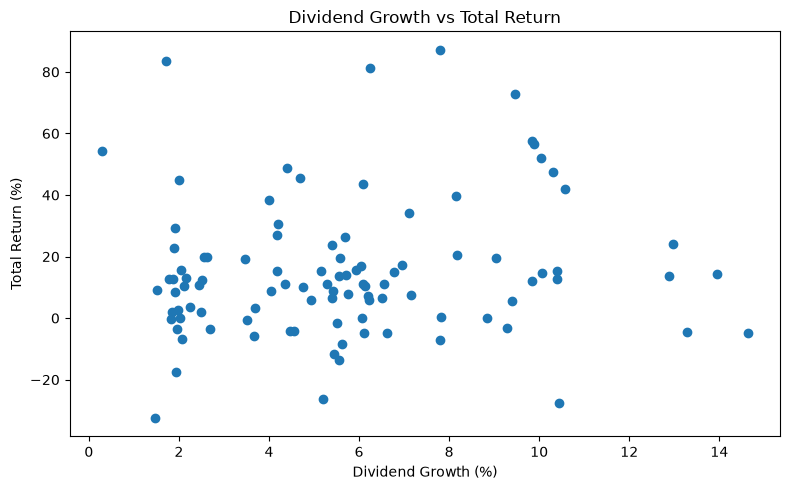

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(
    analysis_data["dividend_growth"],
    analysis_data["total_return"]
)

plt.xlabel("Dividend Growth (%)")
plt.ylabel("Total Return (%)")
plt.title("Dividend Growth vs Total Return")

plt.tight_layout()
plt.show()

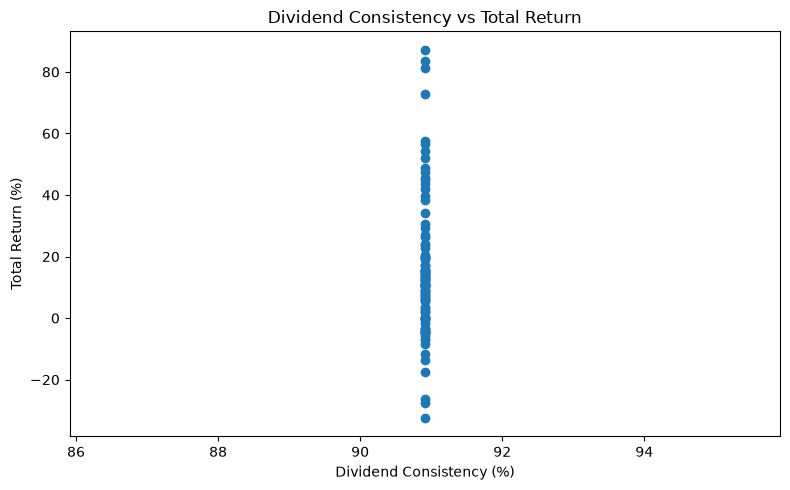

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(
    analysis_data["dividend_consistency"],
    analysis_data["total_return"]
)

plt.xlabel("Dividend Consistency (%)")
plt.ylabel("Total Return (%)")
plt.title("Dividend Consistency vs Total Return")

plt.tight_layout()
plt.show()

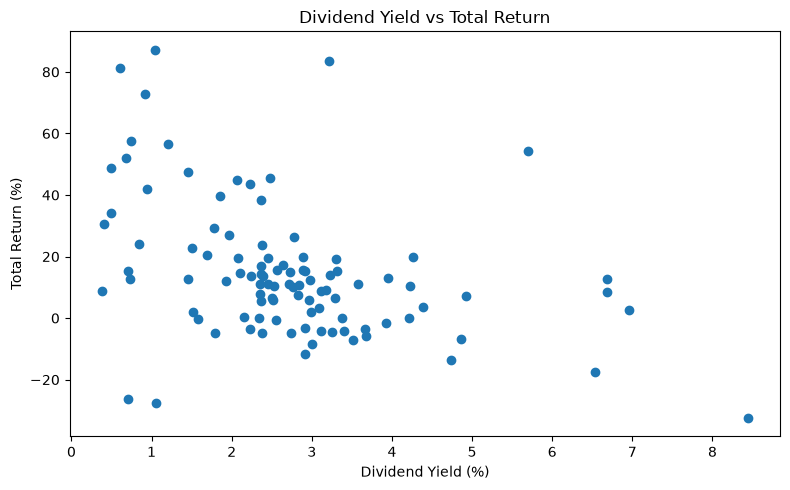

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    analysis_data["dividend_yield"],
    analysis_data["total_return"]
)

plt.xlabel("Dividend Yield (%)")
plt.ylabel("Total Return (%)")
plt.title("Dividend Yield vs Total Return")

plt.tight_layout()
plt.show()

In [12]:
growth_return_corr = analysis_data[
    ["dividend_growth", "total_return"]
].corr().iloc[0, 1]

consistency_return_corr = analysis_data[
    ["dividend_consistency", "total_return"]
].corr().iloc[0, 1]

yield_return_corr = analysis_data[
    ["dividend_yield", "total_return"]
].corr().iloc[0, 1]

growth_stock_corr = analysis_data[
    ["dividend_growth", "annual_stock_return"]
].corr().iloc[0, 1]

print("Dividend Growth vs Total Return:",
      round(growth_return_corr, 4))

print("Dividend Consistency vs Total Return:",
      round(consistency_return_corr, 4))

print("Dividend Yield vs Total Return:",
      round(yield_return_corr, 4))

print("Dividend Growth vs Annual Stock Return:",
      round(growth_stock_corr, 4))

Dividend Growth vs Total Return: 0.1139
Dividend Consistency vs Total Return: nan
Dividend Yield vs Total Return: -0.4089
Dividend Growth vs Annual Stock Return: 0.142


In [13]:
signaling_results = pd.DataFrame({
    "Relationship": [
        "Dividend Growth vs Total Return",
        "Dividend Consistency vs Total Return",
        "Dividend Yield vs Total Return",
        "Dividend Growth vs Annual Stock Return"
    ],
    "Correlation": [
        growth_return_corr,
        consistency_return_corr,
        yield_return_corr,
        growth_stock_corr
    ]
})

signaling_results["Absolute_Correlation"] = (
    signaling_results["Correlation"].abs()
)

print(signaling_results.round(4))

                             Relationship  Correlation  Absolute_Correlation
0         Dividend Growth vs Total Return       0.1139                0.1139
1    Dividend Consistency vs Total Return          NaN                   NaN
2          Dividend Yield vs Total Return      -0.4089                0.4089
3  Dividend Growth vs Annual Stock Return       0.1420                0.1420


In [14]:
signaling_results.to_csv(
    "../datasets/processed/day22_signaling_results.csv",
    index=False
)

print("Day 22 signaling results saved successfully!")

Day 22 signaling results saved successfully!
